[PLANT] Using T=25.0°C: R_s=2.3000, R_r=2.5000
[PLANT] Saturation case=vstrong: L_m=0.1200
[CTRL ] Rated params: R_s=2.3000, R_r=2.5000, L_m=0.2400


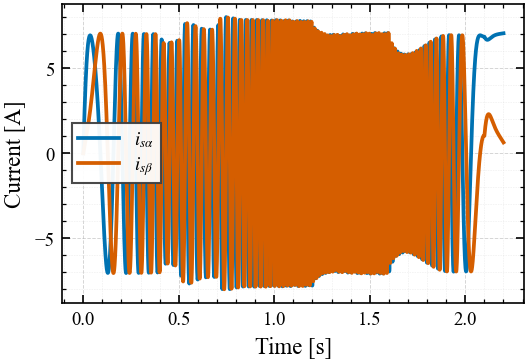

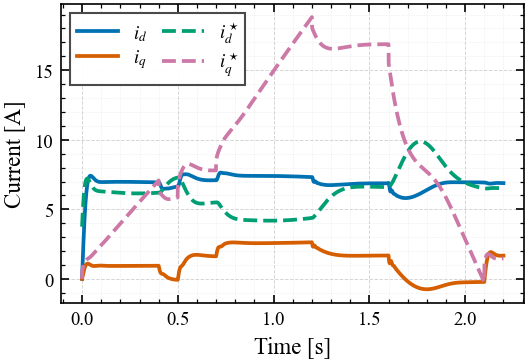

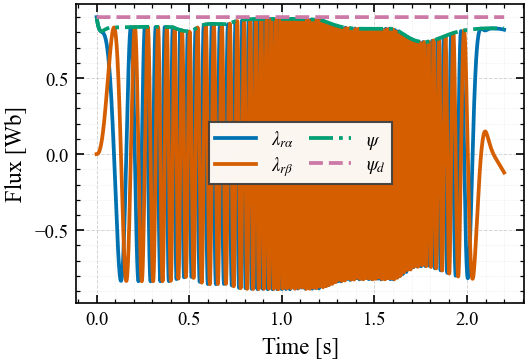

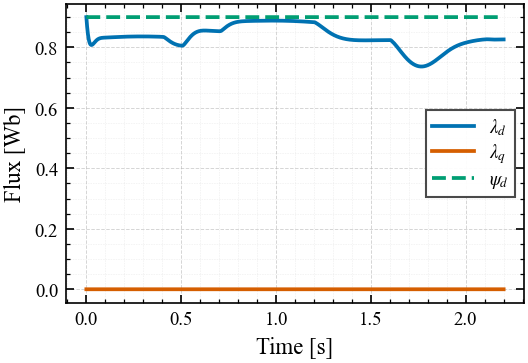

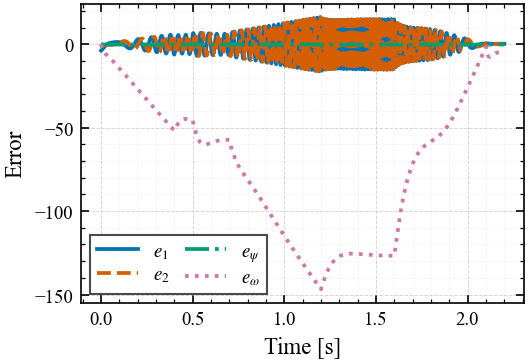

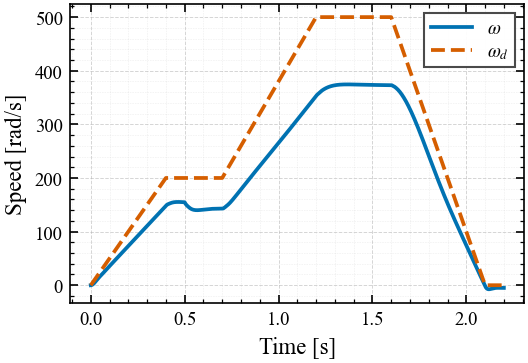

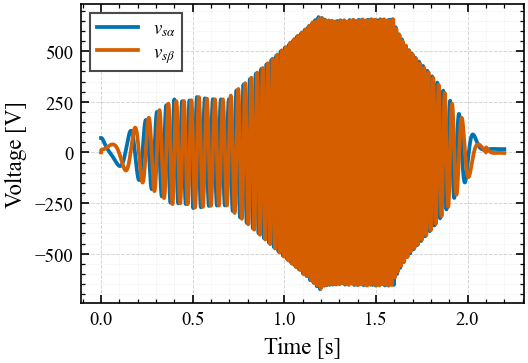

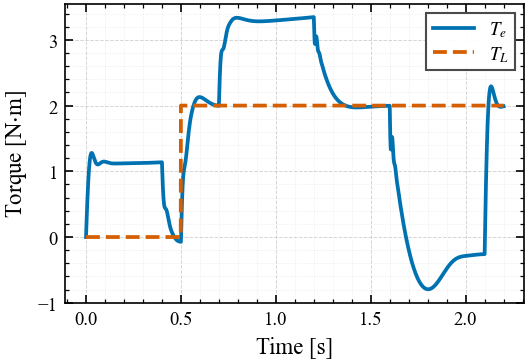

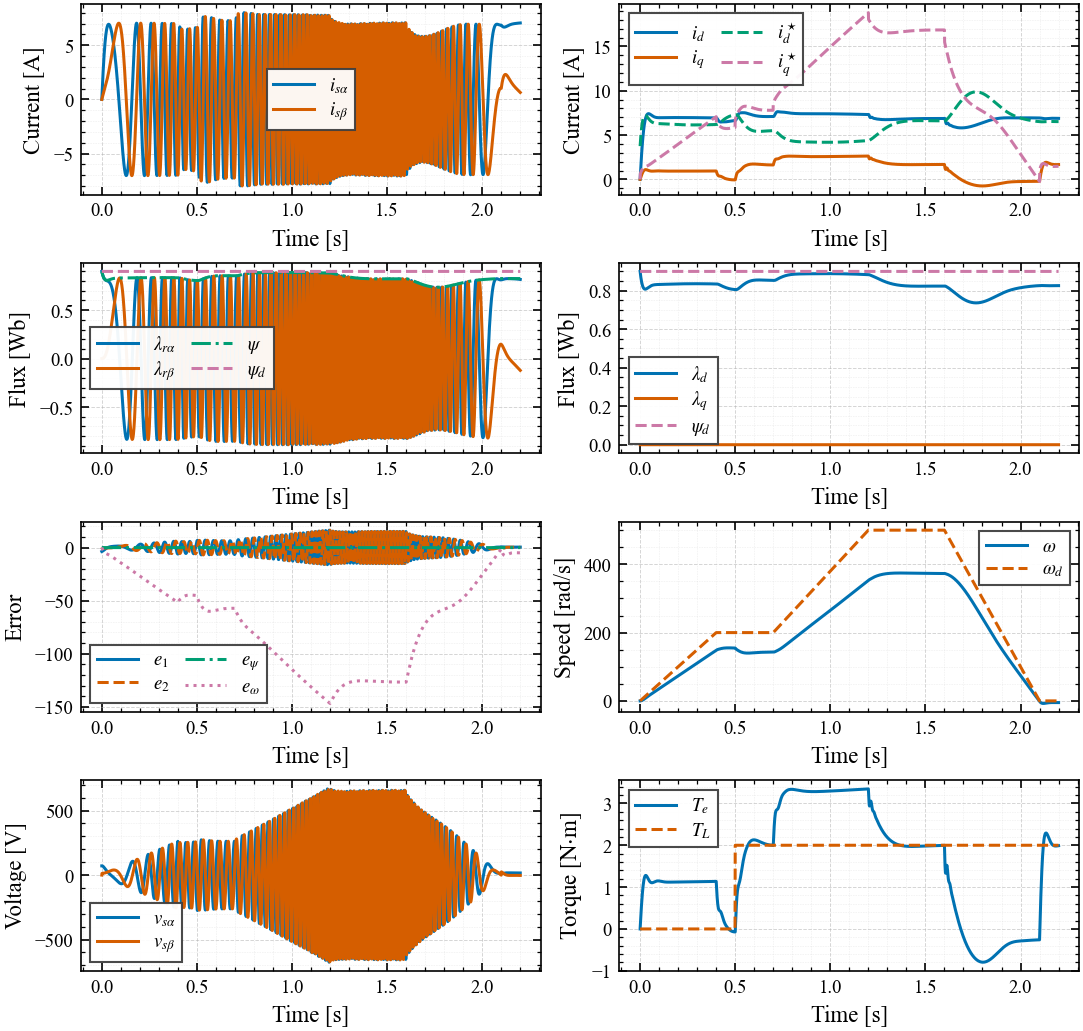

Peak |i_sα|, |i_sβ|: 8.007695880607027 7.98945926964728
Peak |v_sα|, |v_sβ|: 675.6787033614172 672.384524443381


In [6]:
"""
===========================================================
Induction Motor (αβ stationary) + Lyapunov Backstepping Control
===========================================================

This version supports PARAMETER MISMATCH tests:
- Controller uses RATED (nominal) motor parameters: (R_s_ctl, R_r_ctl, L_m_ctl)
- Plant (motor state equations) uses ACTUAL parameters affected by temperature/saturation:
  (R_s, R_r, L_m) set per run.

So: keep controller parameters fixed, and change only plant parameters per run.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# ==========================================================
# IEEE TCST publication-style plotting helpers
# ==========================================================

IEEE_COLORS = [
    "#0072B2",
    "#D55E00",
    "#009E73",
    "#CC79A7",
    "#E69F00",
    "#56B4E9",
    "#000000",
]

IEEE_LINESTYLES = ["-", "--", "-.", ":"]


def set_ieee_plot_style():
    """Set publication-quality defaults for IEEE-style figures."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 0,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "lines.linewidth": 1.8,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
    })


def format_ieee_axes(ax, xlabel=r"Time [s]", ylabel=None, legend_loc="best", ncol=1):
    """Apply consistent axes formatting. No titles are used."""
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, which="major", linestyle="--", linewidth=0.45, alpha=0.55)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.30, alpha=0.35)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="major", length=4, width=0.8)
    ax.tick_params(axis="both", which="minor", length=2, width=0.6)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            loc=legend_loc,
            ncol=ncol,
            frameon=True,
            framealpha=0.95,
            edgecolor="0.25",
            fancybox=False,
            handlelength=2.2,
            borderpad=0.35,
            labelspacing=0.25,
            columnspacing=0.8,
        )


def save_ieee_jpg(fig, filename):
    """Save a figure as a high-resolution JPG using the requested base filename."""
    fig.savefig(f"{filename}.jpg", format="jpg", dpi=600, bbox_inches="tight", pad_inches=0.03)


def plot_two_series(filename, y1, y2, label1, label2, ylabel, linestyle2="-"):
    fig, ax = plt.subplots(figsize=(3.55, 2.45), constrained_layout=True)
    ax.plot(t, y1, color=IEEE_COLORS[0], linestyle="-", linewidth=1.8, label=label1)
    ax.plot(t, y2, color=IEEE_COLORS[1], linestyle=linestyle2, linewidth=1.8, label=label2)
    format_ieee_axes(ax, ylabel=ylabel)
    save_ieee_jpg(fig, filename)
    return fig, ax


def plot_multi_series(filename, series, labels, ylabel, linestyles=None, ncol=1):
    fig, ax = plt.subplots(figsize=(3.55, 2.45), constrained_layout=True)
    if linestyles is None:
        linestyles = [IEEE_LINESTYLES[i % len(IEEE_LINESTYLES)] for i in range(len(series))]
    for i, (y, label) in enumerate(zip(series, labels)):
        ax.plot(
            t,
            y,
            color=IEEE_COLORS[i % len(IEEE_COLORS)],
            linestyle=linestyles[i % len(linestyles)],
            linewidth=1.8,
            label=label,
        )
    format_ieee_axes(ax, ylabel=ylabel, ncol=ncol)
    save_ieee_jpg(fig, filename)
    return fig, ax


# ---- 3-phase supply settings (used only when mode="threephase") ----
V_phase_rms = 80.0     # phase-to-neutral RMS voltage [V]
f_e = 60.0             # electrical frequency [Hz]
phase_offset = 0.0     # rad, optional phase shift

# ==========================================================
# 0) USER EDIT SECTION (easy access)
# ==========================================================

# ---- Motor base parameters ----
L_s = 0.25
L_r = 0.25
p_p = 2
J = 0.003

# ---- Rated motor parameters used INSIDE the controller (fixed) ----
R_s_ctl = 2.3
R_r_ctl = 2.5
L_m_ctl = 0.24

# ---- Temperature scenario for the PLANT (choose ONE temperature and run) ----
T_ref = 25.0
alpha_Cu = 0.00393

R_s_ref = 2.3   # nominal at T_ref
R_r_ref = 2.5

T_C = 25.0      # <-- change to 80, 120, etc. and re-run

R_s = R_s_ref * (1.0 + alpha_Cu * (T_C - T_ref))   # PLANT Rs
R_r = R_r_ref * (1.0 + alpha_Cu * (T_C - T_ref))   # PLANT Rr
print(f"[PLANT] Using T={T_C}°C: R_s={R_s:.4f}, R_r={R_r:.4f}")

# ---- Saturation scenario for the PLANT (fixed Lm per run) ----
Lm_nom = 0.24
sat_case = "vstrong"     # "none", "mild", "strong"

if sat_case == "none":
    L_m = Lm_nom
elif sat_case == "mild":
    L_m = 0.90 * Lm_nom   # 10% drop
elif sat_case == "strong":
    L_m = 0.75 * Lm_nom   # 25% drop
elif sat_case == "vstrong":
    L_m = 0.5 * Lm_nom   # 50% drop
else:
    raise ValueError("Unknown sat_case")
print(f"[PLANT] Saturation case={sat_case}: L_m={L_m:.4f}")

# ---- Controller gains ----
k_psi = 100.0   # flux magnitude tracking gain
k_w   = 100.0   # speed tracking gain
k1    = 10*k_psi   # current tracking gain for i_sα
k2    = 10*k_psi   # current tracking gain for i_sβ

# ---- Simulation settings ----
t0 = 0.0
tf = 2.2
dt_out = 1e-3
rtol = 1e-7
atol = 1e-9
method = "RK45"  # try "Radau" if stiff

# ---- Mode selection ----
mode = "controller"   # "controller" or "threephase"

# ---- Speed reference settings ----
w_type = "profile"  # "step","ramp","sine","profile","custom"

w_step = 200.0

w_ramp_t0 = 0.1
w_ramp_t1 = 0.8
w_ramp_slope = 250.0

w_sine_amp = 50.0
w_sine_bias = 150.0
w_sine_freq_hz = 1.0

w_profile = (
    (0.0, 0.4, 0.0, 200.0),
    (0.4, 0.7, 200.0, 200.0),
    (0.7, 1.2, 200.0, 500.0),
    (1.2, 1.6, 500.0, 500.0),
    (1.6, 2.1, 500.0, 0.0),
)

def w_custom(t: float):
    w = 100.0 + 50.0*np.sin(2*np.pi*0.5*t)
    dw = 50.0*(2*np.pi*0.5)*np.cos(2*np.pi*0.5*t)
    ddw = -50.0*(2*np.pi*0.5)**2*np.sin(2*np.pi*0.5*t)
    return w, dw, ddw


# ---- Flux magnitude reference settings ----
psi_type = "constant"  # "constant","step","ramp","sine","custom"
psi_const = 0.9

psi_step_t0 = 0.1
psi_step = 0.9

psi_ramp_t0 = 0.1
psi_ramp_t1 = 0.8
psi_ramp_slope = 0.2

psi_sine_amp = 0.1
psi_sine_bias = 0.8
psi_sine_freq_hz = 0.5

def psi_custom(t: float):
    psi = 0.9
    return psi, 0.0, 0.0


# ---- Load torque settings ----
TL_type = "step"  # "constant","step","sine","custom"
TL_const = 1.0

TL_step_t0 = 0.5
TL_step = 2.0

TL_sine_amp = 0.5
TL_sine_bias = 1.0
TL_sine_freq_hz = 1.0

def TL_custom(t: float):
    TL = 1.0
    return TL, 0.0


# ---- Initial condition: x0 = [i_sα, i_sβ, λ_rα, λ_rβ, ω] ----
# Start at rated flux magnitude for smooth startup
x0 = np.array([0.0, 0.0, psi_const, 0.0, 0.0], dtype=float)

# safety floor for division by psi inside controller (optional but robust)
psi_floor = 1e-3


# ==========================================================
# 1) Motor coefficient helper + plant/controller coefficient sets
# ==========================================================

def motor_coeffs(Rs, Rr, Lm, Ls, Lr, p_p, J):
    L_sigma = Ls * (1.0 - (Lm**2) / (Ls * Lr))

    a_s = Rs / L_sigma + (Rr * Lm**2) / (Lr**2 * L_sigma)
    b_s = (Rr * Lm) / (Lr**2 * L_sigma)
    c_s = Lm / (L_sigma * Lr)

    alpha = (Rr * Lm) / Lr
    beta  = - Rr / Lr
    gamma = (3.0/2.0) * (p_p / J) * (Lm / Lr)

    return L_sigma, a_s, b_s, c_s, alpha, beta, gamma


# Plant (actual) coeffs used in MOTOR STATE EQUATIONS
L_sigma_p, a_s_p, b_s_p, c_s_p, alpha_p, beta_p, gamma_p = motor_coeffs(
    R_s, R_r, L_m, L_s, L_r, p_p, J
)

# Controller (rated) coeffs used in CONTROL COMPUTATIONS
L_sigma_c, a_s_c, b_s_c, c_s_c, alpha_c, beta_c, gamma_c = motor_coeffs(
    R_s_ctl, R_r_ctl, L_m_ctl, L_s, L_r, p_p, J
)

print(f"[CTRL ] Rated params: R_s={R_s_ctl:.4f}, R_r={R_r_ctl:.4f}, L_m={L_m_ctl:.4f}")


# ==========================================================
# 2) Reference and load functions
# ==========================================================

def ref_step_fn(t: float, t_sw: float, value: float, bias: float = 0.0):
    r = bias + (value if t >= t_sw else 0.0)
    return r, 0.0, 0.0

def ref_ramp_fn(t: float, t0: float, t1: float, slope: float, bias: float = 0.0):
    if t < t0:
        return bias, 0.0, 0.0
    if t < t1:
        r = bias + slope*(t - t0)
        return r, slope, 0.0
    r = bias + slope*(t1 - t0)
    return r, 0.0, 0.0

def ref_sine_fn(t: float, amp: float, bias: float, freq_hz: float):
    w = 2.0*np.pi*freq_hz
    r = bias + amp*np.sin(w*t)
    dr = amp*w*np.cos(w*t)
    ddr = -amp*(w**2)*np.sin(w*t)
    return r, dr, ddr

def ref_piecewise_linear_fn(t: float, segments):
    t0_first, t1_first, y0_first, y1_first = segments[0]
    if t <= t0_first:
        return y0_first, 0.0, 0.0

    for (t0_, t1_, y0_, y1_) in segments:
        if t0_ <= t <= t1_:
            if abs(t1_ - t0_) < 1e-12:
                return y1_, 0.0, 0.0
            slope = (y1_ - y0_) / (t1_ - t0_)
            y = y0_ + slope*(t - t0_)
            return y, slope, 0.0

    return segments[-1][3], 0.0, 0.0

def speed_reference(t: float):
    if w_type == "step":
        return ref_step_fn(t, 0.0, w_step, 0.0)
    if w_type == "ramp":
        return ref_ramp_fn(t, w_ramp_t0, w_ramp_t1, w_ramp_slope, 0.0)
    if w_type == "sine":
        return ref_sine_fn(t, w_sine_amp, w_sine_bias, w_sine_freq_hz)
    if w_type == "profile":
        return ref_piecewise_linear_fn(t, w_profile)
    if w_type == "custom":
        return w_custom(t)
    raise ValueError(f"Unknown w_type: {w_type}")

def flux_reference(t: float):
    if psi_type == "constant":
        return psi_const, 0.0, 0.0
    if psi_type == "step":
        return ref_step_fn(t, psi_step_t0, psi_step, 0.0)
    if psi_type == "ramp":
        return ref_ramp_fn(t, psi_ramp_t0, psi_ramp_t1, psi_ramp_slope, 0.0)
    if psi_type == "sine":
        return ref_sine_fn(t, psi_sine_amp, psi_sine_bias, psi_sine_freq_hz)
    if psi_type == "custom":
        return psi_custom(t)
    raise ValueError(f"Unknown psi_type: {psi_type}")

def load_torque(t: float):
    if TL_type == "constant":
        return TL_const, 0.0
    if TL_type == "step":
        TL = TL_step if t >= TL_step_t0 else 0.0
        return TL, 0.0
    if TL_type == "sine":
        w_ = 2.0*np.pi*TL_sine_freq_hz
        TL = TL_sine_bias + TL_sine_amp*np.sin(w_*t)
        dTL = TL_sine_amp*w_*np.cos(w_*t)
        return TL, dTL
    if TL_type == "custom":
        return TL_custom(t)
    raise ValueError(f"Unknown TL_type: {TL_type}")


def three_phase_voltages(t: float, V_phase_rms: float, f_e: float, phase_offset: float = 0.0):
    w_ = 2.0 * np.pi * f_e
    Vp = np.sqrt(2.0) * V_phase_rms  # peak
    va = Vp * np.sin(w_*t + phase_offset)
    vb = Vp * np.sin(w_*t + phase_offset - 2.0*np.pi/3.0)
    vc = Vp * np.sin(w_*t + phase_offset + 2.0*np.pi/3.0)
    return va, vb, vc

def abc_to_alphabeta(va: float, vb: float, vc: float):
    v_alpha = (2.0/3.0) * (va - 0.5*vb - 0.5*vc)
    v_beta  = (2.0/3.0) * (np.sqrt(3.0)/2.0) * (vb - vc)
    return v_alpha, v_beta

def supply_u_alphabeta(t: float):
    va, vb, vc = three_phase_voltages(t, V_phase_rms, f_e, phase_offset)
    return abc_to_alphabeta(va, vb, vc)


# ==========================================================
# 3) dq frame aligned with rotor flux λ_r
# ==========================================================

Jmat = np.array([[0.0, -1.0],
                 [1.0,  0.0]])

def dq_from_state(x: np.ndarray):
    x1, x2, x3, x4, _w = x
    lam = np.array([x3, x4], dtype=float)
    psi = float(np.sqrt(x3*x3 + x4*x4))
    psi = max(psi, 1e-8)

    e_d = lam / psi
    e_q = Jmat @ e_d

    i_s = np.array([x1, x2], dtype=float)
    i_d = float(e_d @ i_s)
    i_q = float(e_q @ i_s)

    lam_d = float(e_d @ lam)
    lam_q = float(e_q @ lam)

    return psi, e_d, e_q, i_d, i_q, lam_d, lam_q


# ==========================================================
# 4) Closed-loop RHS: controller + plant (with mismatch)
# ==========================================================

def closed_loop_rhs(t: float, x: np.ndarray):
    x1, x2, x3, x4, w = x

    # references
    w_d, dw_d, ddw_d = speed_reference(t)
    psi_d, dpsi_d, ddpsi_d = flux_reference(t)

    # load
    TL, dTL = load_torque(t)

    # dq quantities
    psi, e_d, e_q, i_d, i_q, _, _ = dq_from_state(x)

    # --- PLANT rotor flux derivatives ---
    dx3 = alpha_p*x1 + beta_p*x3 - w*x4
    dx4 = alpha_p*x2 + beta_p*x4 + w*x3
    lam = np.array([x3, x4], dtype=float)
    dlam = np.array([dx3, dx4], dtype=float)

    # --- PLANT identities ---
    dpsi = alpha_p*i_d + beta_p*psi
    dw = gamma_p*psi*i_q - (1.0/J)*TL

    # ---------------- Outer loop ----------------
    e_psi = psi - psi_d
    e_w = w - w_d

    # --- CONTROLLER virtual controls (rated model) ---
    i_d_star = (dpsi_d - beta_c*psi - k_psi*e_psi) / alpha_c

    num = (dw_d + (1.0/J)*TL - k_w*e_w)
    psi_eff = max(psi, psi_floor)
    i_q_star = num / (gamma_c * psi_eff)

    # derivatives of virtual controls (controller model)
    di_d_star = (ddpsi_d - beta_c*dpsi - k_psi*(dpsi - dpsi_d)) / alpha_c

    de_w = dw - dw_d
    dnum = ddw_d + (1.0/J)*dTL - k_w*de_w
    di_q_star = (dnum*psi_eff - num*dpsi) / (gamma_c*(psi_eff**2))

    # ---------------- Desired current vector in αβ ----------------
    de_d = (dlam / psi_eff) - lam * (dpsi / (psi_eff**2))
    de_q = Jmat @ de_d

    i_s_d = i_d_star*e_d + i_q_star*e_q
    di_s_d = di_d_star*e_d + i_d_star*de_d + di_q_star*e_q + i_q_star*de_q

    x1d, x2d = float(i_s_d[0]), float(i_s_d[1])
    dx1d, dx2d = float(di_s_d[0]), float(di_s_d[1])

    e1 = x1 - x1d
    e2 = x2 - x2d

    # ---------------- Real inputs u1,u2 ----------------
    if mode == "controller":
        # controller uses RATED coefficients
        u1 = L_sigma_c * (dx1d + a_s_c*x1 - b_s_c*x3 - c_s_c*w*x4 - k1*e1)
        u2 = L_sigma_c * (dx2d + a_s_c*x2 - b_s_c*x4 + c_s_c*w*x3 - k2*e2)
    elif mode == "threephase":
        u1, u2 = supply_u_alphabeta(t)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    # ---------------- PLANT dynamics (actual coefficients) ----------------
    dx1 = -a_s_p*x1 + b_s_p*x3 + c_s_p*w*x4 + (1.0/L_sigma_p)*u1
    dx2 = -a_s_p*x2 + b_s_p*x4 - c_s_p*w*x3 + (1.0/L_sigma_p)*u2
    dx5 = dw

    return np.array([dx1, dx2, dx3, dx4, dx5], dtype=float)


# ==========================================================
# 5) Simulate
# ==========================================================

t_eval = np.arange(t0, tf + dt_out, dt_out)

sol = solve_ivp(
    fun=closed_loop_rhs,
    t_span=(t0, tf),
    y0=x0,
    t_eval=t_eval,
    rtol=rtol,
    atol=atol,
    method=method,
)

if not sol.success:
    raise RuntimeError("Integration failed: " + str(sol.message))

t = sol.t
X = sol.y.T  # (N,5)


# ==========================================================
# 6) Postprocess for plots (consistent with mismatch)
# ==========================================================

N = len(t)
u_hist = np.zeros((N, 2))
TL_hist = np.zeros(N)

w_d_hist = np.zeros(N)
psi_d_hist = np.zeros(N)
psi_hist = np.zeros(N)

e1_hist = np.zeros(N)
e2_hist = np.zeros(N)
epsi_hist = np.zeros(N)
ew_hist = np.zeros(N)

id_hist = np.zeros(N)
iq_hist = np.zeros(N)
id_star_hist = np.zeros(N)
iq_star_hist = np.zeros(N)

lamd_hist = np.zeros(N)
lamq_hist = np.zeros(N)

for k, tk in enumerate(t):
    x = X[k, :].copy()
    x1, x2, x3, x4, w = x

    w_d, dw_d, ddw_d = speed_reference(tk)
    psi_d, dpsi_d, ddpsi_d = flux_reference(tk)
    TL, dTL = load_torque(tk)

    w_d_hist[k] = w_d
    psi_d_hist[k] = psi_d
    TL_hist[k] = TL

    psi, e_d, e_q, i_d, i_q, lam_d, lam_q = dq_from_state(x)
    psi_hist[k] = psi
    id_hist[k] = i_d
    iq_hist[k] = i_q
    lamd_hist[k] = lam_d
    lamq_hist[k] = lam_q

    # PLANT flux derivatives
    dx3 = alpha_p*x1 + beta_p*x3 - w*x4
    dx4 = alpha_p*x2 + beta_p*x4 + w*x3
    lam = np.array([x3, x4], dtype=float)
    dlam = np.array([dx3, dx4], dtype=float)

    # PLANT identities
    dpsi = alpha_p*i_d + beta_p*psi
    dw = gamma_p*psi*i_q - (1.0/J)*TL

    # outer errors
    e_psi = psi - psi_d
    e_w = w - w_d
    epsi_hist[k] = e_psi
    ew_hist[k] = e_w

    # CONTROLLER virtual controls
    i_d_star = (dpsi_d - beta_c*psi - k_psi*e_psi) / alpha_c
    num = (dw_d + (1.0/J)*TL - k_w*e_w)
    psi_eff = max(psi, psi_floor)
    i_q_star = num / (gamma_c*psi_eff)

    id_star_hist[k] = i_d_star
    iq_star_hist[k] = i_q_star

    # derivatives (controller-side)
    di_d_star = (ddpsi_d - beta_c*dpsi - k_psi*(dpsi - dpsi_d)) / alpha_c
    de_w = dw - dw_d
    dnum = ddw_d + (1.0/J)*dTL - k_w*de_w
    di_q_star = (dnum*psi_eff - num*dpsi) / (gamma_c*(psi_eff**2))

    de_d = (dlam / psi_eff) - lam * (dpsi / (psi_eff**2))
    de_q = Jmat @ de_d

    i_s_d = i_d_star*e_d + i_q_star*e_q
    di_s_d = di_d_star*e_d + i_d_star*de_d + di_q_star*e_q + i_q_star*de_q

    x1d, x2d = float(i_s_d[0]), float(i_s_d[1])
    dx1d, dx2d = float(di_s_d[0]), float(di_s_d[1])

    e1 = x1 - x1d
    e2 = x2 - x2d
    e1_hist[k] = e1
    e2_hist[k] = e2

    # controller voltages (rated)
    if mode == "controller":
        u1 = L_sigma_c * (dx1d + a_s_c*x1 - b_s_c*x3 - c_s_c*w*x4 - k1*e1)
        u2 = L_sigma_c * (dx2d + a_s_c*x2 - b_s_c*x4 + c_s_c*w*x3 - k2*e2)
    else:
        u1, u2 = supply_u_alphabeta(tk)

    u_hist[k, 0] = u1
    u_hist[k, 1] = u2


# electromagnetic torque (PLANT gamma)
Te_hist = J * gamma_p * psi_hist * iq_hist   # [N·m]


# ==========================================================
# 7) Publication-quality IEEE TCST figures
# ==========================================================

set_ieee_plot_style()

x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]
x4 = X[:, 3]
w  = X[:, 4]

# ----------------------------------------------------------
# Figure set: separate publication-ready panels
# ----------------------------------------------------------
plot_two_series(
    "im_currents_alphabeta",
    x1,
    x2,
    r"$i_{s\alpha}$",
    r"$i_{s\beta}$",
    r"Current [A]",
)

plot_multi_series(
    "im_currents_dq",
    [id_hist, iq_hist, id_star_hist, iq_star_hist],
    [r"$i_d$", r"$i_q$", r"$i_d^\star$", r"$i_q^\star$"],
    r"Current [A]",
    linestyles=["-", "-", "--", "--"],
    ncol=2,
)

plot_multi_series(
    "im_flux_alphabeta",
    [x3, x4, psi_hist, psi_d_hist],
    [r"$\lambda_{r\alpha}$", r"$\lambda_{r\beta}$", r"$\psi$", r"$\psi_d$"],
    r"Flux [Wb]",
    linestyles=["-", "-", "-.", "--"],
    ncol=2,
)

plot_multi_series(
    "im_flux_dq",
    [lamd_hist, lamq_hist, psi_d_hist],
    [r"$\lambda_d$", r"$\lambda_q$", r"$\psi_d$"],
    r"Flux [Wb]",
    linestyles=["-", "-", "--"],
)

plot_multi_series(
    "im_tracking_errors",
    [e1_hist, e2_hist, epsi_hist, ew_hist],
    [r"$e_1$", r"$e_2$", r"$e_\psi$", r"$e_\omega$"],
    r"Error",
    linestyles=["-", "--", "-.", ":"],
    ncol=2,
)

plot_two_series(
    "im_speed",
    w,
    w_d_hist,
    r"$\omega$",
    r"$\omega_d$",
    r"Speed [rad/s]",
    linestyle2="--",
)

plot_two_series(
    "im_control",
    u_hist[:, 0],
    u_hist[:, 1],
    r"$v_{s\alpha}$",
    r"$v_{s\beta}$",
    r"Voltage [V]",
)

plot_two_series(
    "im_torque",
    Te_hist,
    TL_hist,
    r"$T_e$",
    r"$T_L$",
    r"Torque [N$\cdot$m]",
    linestyle2="--",
)

# ----------------------------------------------------------
# Optional combined dashboard, also title-free and IEEE-styled
# ----------------------------------------------------------
fig, ax = plt.subplots(4, 2, figsize=(7.25, 6.9), constrained_layout=True)

ax[0, 0].plot(t, x1, color=IEEE_COLORS[0], linewidth=1.45, label=r"$i_{s\alpha}$")
ax[0, 0].plot(t, x2, color=IEEE_COLORS[1], linewidth=1.45, label=r"$i_{s\beta}$")
format_ieee_axes(ax[0, 0], ylabel=r"Current [A]")

ax[0, 1].plot(t, id_hist, color=IEEE_COLORS[0], linewidth=1.45, label=r"$i_d$")
ax[0, 1].plot(t, iq_hist, color=IEEE_COLORS[1], linewidth=1.45, label=r"$i_q$")
ax[0, 1].plot(t, id_star_hist, color=IEEE_COLORS[2], linestyle="--", linewidth=1.45, label=r"$i_d^\star$")
ax[0, 1].plot(t, iq_star_hist, color=IEEE_COLORS[3], linestyle="--", linewidth=1.45, label=r"$i_q^\star$")
format_ieee_axes(ax[0, 1], ylabel=r"Current [A]", ncol=2)

ax[1, 0].plot(t, x3, color=IEEE_COLORS[0], linewidth=1.45, label=r"$\lambda_{r\alpha}$")
ax[1, 0].plot(t, x4, color=IEEE_COLORS[1], linewidth=1.45, label=r"$\lambda_{r\beta}$")
ax[1, 0].plot(t, psi_hist, color=IEEE_COLORS[2], linestyle="-.", linewidth=1.45, label=r"$\psi$")
ax[1, 0].plot(t, psi_d_hist, color=IEEE_COLORS[3], linestyle="--", linewidth=1.45, label=r"$\psi_d$")
format_ieee_axes(ax[1, 0], ylabel=r"Flux [Wb]", ncol=2)

ax[1, 1].plot(t, lamd_hist, color=IEEE_COLORS[0], linewidth=1.45, label=r"$\lambda_d$")
ax[1, 1].plot(t, lamq_hist, color=IEEE_COLORS[1], linewidth=1.45, label=r"$\lambda_q$")
ax[1, 1].plot(t, psi_d_hist, color=IEEE_COLORS[3], linestyle="--", linewidth=1.45, label=r"$\psi_d$")
format_ieee_axes(ax[1, 1], ylabel=r"Flux [Wb]")

ax[2, 0].plot(t, e1_hist, color=IEEE_COLORS[0], linewidth=1.45, label=r"$e_1$")
ax[2, 0].plot(t, e2_hist, color=IEEE_COLORS[1], linestyle="--", linewidth=1.45, label=r"$e_2$")
ax[2, 0].plot(t, epsi_hist, color=IEEE_COLORS[2], linestyle="-.", linewidth=1.45, label=r"$e_\psi$")
ax[2, 0].plot(t, ew_hist, color=IEEE_COLORS[3], linestyle=":", linewidth=1.45, label=r"$e_\omega$")
format_ieee_axes(ax[2, 0], ylabel=r"Error", ncol=2)

ax[2, 1].plot(t, w, color=IEEE_COLORS[0], linewidth=1.45, label=r"$\omega$")
ax[2, 1].plot(t, w_d_hist, color=IEEE_COLORS[1], linestyle="--", linewidth=1.45, label=r"$\omega_d$")
format_ieee_axes(ax[2, 1], ylabel=r"Speed [rad/s]")

ax[3, 0].plot(t, u_hist[:, 0], color=IEEE_COLORS[0], linewidth=1.45, label=r"$v_{s\alpha}$")
ax[3, 0].plot(t, u_hist[:, 1], color=IEEE_COLORS[1], linewidth=1.45, label=r"$v_{s\beta}$")
format_ieee_axes(ax[3, 0], ylabel=r"Voltage [V]")

ax[3, 1].plot(t, Te_hist, color=IEEE_COLORS[0], linewidth=1.45, label=r"$T_e$")
ax[3, 1].plot(t, TL_hist, color=IEEE_COLORS[1], linestyle="--", linewidth=1.45, label=r"$T_L$")
format_ieee_axes(ax[3, 1], ylabel=r"Torque [N$\cdot$m]")

save_ieee_jpg(fig, "im_mismatch_dashboard")

plt.show()

# Optional: print peaks for quick comparison across runs
print("Peak |i_sα|, |i_sβ|:", np.max(np.abs(x1)), np.max(np.abs(x2)))
print("Peak |v_sα|, |v_sβ|:", np.max(np.abs(u_hist[:, 0])), np.max(np.abs(u_hist[:, 1])))